In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- CONFIGURATION ---
SCALE = 'agglomeration' # Choose: 'canton', 'agglomeration', 'district', 'commune'

# Paths
DIAGRAMS_DIR = f'../Persistence_Diagrams/{SCALE}'
GEODATA_BASE = '../geodata/'

# Dictionary mapping the scale to the correct shapefile and ID column
shapefile_configs = {
    'canton': {'file': 'boundaries/Cantons_G0_18600101.shp', 'id_col': 'KTKZ'},
    'agglomeration': {'file': 'agglomerations/k4a24_12.shp', 'id_col': 'AgglName'},
    'district': {'file': 'boundaries/Districts_G0_18600101.shp', 'id_col': 'BEZNAME'},
    'commune': {'file': 'boundaries/Communes_G0_18600101.shp', 'id_col': 'GDENAME'}
}

shapefile_path = os.path.join(GEODATA_BASE, shapefile_configs[SCALE]['file'])
shapefile_id_col = shapefile_configs[SCALE]['id_col']

In [3]:
# --- 1. VECTORIZATION: PERSISTENCE STATISTICS ---
def compute_persistence_statistics(diagram):
    """
    Implements the 'Persistence Statistics' vectorization from the survey paper.
    Calculates summary stats for births, deaths, midpoints, and lifespans.
    """
    # SAFETY FIX: The computed feature length below is exactly 38.
    if len(diagram) == 0:
        return np.zeros(38)

    # Extract features. Cap infinity to a max time (e.g., 9000s) to avoid NaNs.
    diagram = np.where(np.isinf(diagram), 9000.0, diagram)

    births = diagram[:, 0]
    deaths = diagram[:, 1]
    lifespans = deaths - births
    midpoints = (births + deaths) / 2.0

    features = []

    # Calculate stats for each metric
    for metric in [births, deaths, midpoints, lifespans]:
        # If there's only 1 point, IQR and PTP can be 0 or throw warnings, handle safely
        if len(metric) == 1:
            features.extend([
                np.mean(metric), np.std(metric), np.median(metric),
                0.0, 0.0, # IQR and Range are 0 for a single point
                metric[0], metric[0], metric[0], metric[0] # Percentiles are just the value
            ])
        else:
            features.extend([
                np.mean(metric),
                np.std(metric),
                np.median(metric),
                stats.iqr(metric),
                np.ptp(metric), # Full range
                np.percentile(metric, 10),
                np.percentile(metric, 25),
                np.percentile(metric, 75),
                np.percentile(metric, 90)
            ])

    # Total number of bars
    features.append(len(diagram))

    # Persistent Entropy
    L = np.sum(lifespans)
    if L > 0:
        p_i = lifespans / L
        entropy = -np.sum(p_i * np.log(p_i + 1e-10))
    else:
        entropy = 0.0
    features.append(entropy)

    return np.array(features)

def vectorize_city(npz_path):
    """Loads H0 and H1, computes stats, and concatenates them."""
    data = np.load(npz_path)
    h0, h1 = data['h0'], data['h1']

    vec_h0 = compute_persistence_statistics(h0)
    vec_h1 = compute_persistence_statistics(h1)

    return np.concatenate([vec_h0, vec_h1])


# --- 2. CLUSTERING WRAPPER ---
def cluster_regions(feature_matrix, method=KMeans, **kwargs):
    """
    Scales the data and applies any sklearn clustering algorithm.
    """
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(feature_matrix)

    model = method(**kwargs)
    cluster_labels = model.fit_predict(scaled_features)

    return cluster_labels

In [4]:
# --- IMPORTS NEEDED FOR THIS CELL ---
import sys
sys.path.append('.') # Ensure current directory is in path
# Import your exact dictionaries
from name_mappings import canton_names, agglomerations_names, district_names, comune_names

print(f"Loading data for scale: {SCALE.upper()}")

city_keys = []
raw_names = []
feature_vectors = []

# 1. Setup the Dictionary Mapping
mapping_dicts = {
    'canton': canton_names,
    'agglomeration': agglomerations_names,
    'district': district_names,
    'commune': comune_names
}
current_mapping = mapping_dicts[SCALE]

# 2. Load and Vectorize
for file in os.listdir(DIAGRAMS_DIR):
    if file.endswith("_diagrams.npz"):
        # Extract the clean city key from the filename
        clean_key = file.replace("_diagrams.npz", "")
        file_path = os.path.join(DIAGRAMS_DIR, file)

        # Look up the EXACT string needed for the shapefile
        # If it's somehow not in the dict, just use the clean key as a fallback
        raw_name = current_mapping.get(clean_key, clean_key)

        try:
            vec = vectorize_city(file_path)
            vec = np.nan_to_num(vec)

            city_keys.append(clean_key)
            raw_names.append(raw_name)
            feature_vectors.append(vec)
        except Exception as e:
            print(f"Failed to process {file}: {e}")

feature_matrix = np.array(feature_vectors)
print(f"Constructed feature matrix with shape: {feature_matrix.shape}")

# 3. Cluster
CLUSTER_METHOD = KMeans
CLUSTER_KWARGS = {'n_clusters': 5, 'random_state': 42}

print(f"Running {CLUSTER_METHOD.__name__} with params: {CLUSTER_KWARGS}")
labels = cluster_regions(feature_matrix, method=CLUSTER_METHOD, **CLUSTER_KWARGS)

# 4. Build Results DataFrame
results_df = pd.DataFrame({
    'clean_key': city_keys,
    'shapefile_name': raw_names, # This is the exact string we will join on!
    'cluster': labels
})

print("\nSample of matched names:")
print(results_df.head())

Loading data for scale: AGGLOMERATION
Constructed feature matrix with shape: (78, 76)
Running KMeans with params: {'n_clusters': 5, 'random_state': 42}

Sample of matched names:
         clean_key     shapefile_name  cluster
0        oensingen          Oensingen        1
1  arbon_rorschach  Arbon – Rorschach        2
2        landquart          Landquart        1
3       bellinzona         Bellinzona        1
4         grenchen           Grenchen        1


In [5]:
# 1. Load the geographic boundaries
print(f"Loading shapefile: {shapefile_path}")
gdf = gpd.read_file(shapefile_path)

# 2. Merge the clustering results into the geographic dataframe
# We do a Left join on the shapefile so areas we didn't process just show up as 'NaN' or grey.
merged_gdf = gdf.merge(results_df, left_on=shapefile_id_col, right_on='shapefile_name', how='left')

# Convert cluster labels to strings so the map treats them as categorical colors, not a continuous gradient
merged_gdf['cluster'] = merged_gdf['cluster'].astype(str)
merged_gdf['cluster'] = merged_gdf['cluster'].replace('nan', 'Not Processed')

# 3. Plot an interactive interactive map using geopandas.explore()
# This handles all the folium backend automatically!
m = merged_gdf.explore(
    column='cluster',
    cmap='Set1',          # A nice categorical color palette
    tooltip=[shapefile_id_col, 'cluster'],
    popup=True,
    tiles='CartoDB positron',
    style_kwds={'fillOpacity': 0.7, 'weight': 1.0},
    name="Transit Topologies"
)

# Display the map
m

Loading shapefile: ../geodata/agglomerations/k4a24_12.shp


Reducing 76D topological feature space to 2D using UMAP...


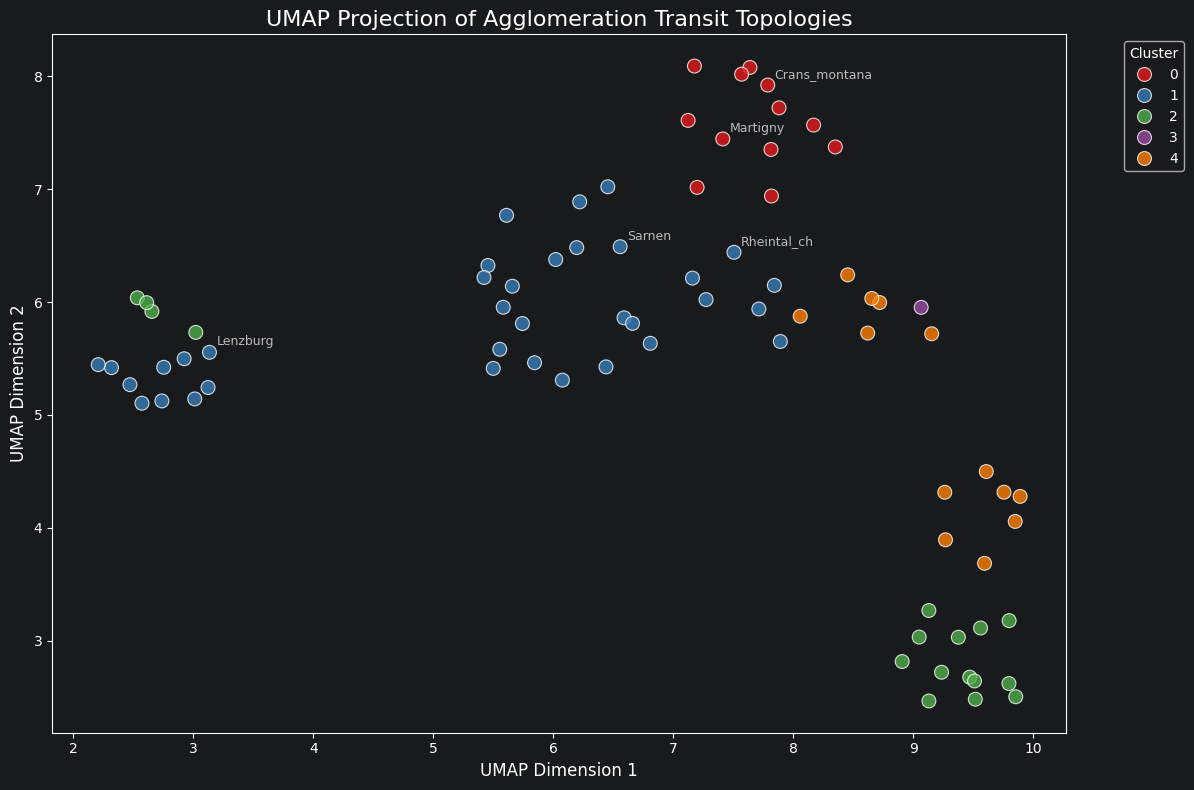

In [6]:
import umap
import seaborn as sns
import matplotlib.pyplot as plt

print("Reducing 76D topological feature space to 2D using UMAP...")

# 1. Scale the features (UMAP relies on distance metrics, so scaling is critical)
# We re-scale here just in case the previous scaler was locked inside the function
scaler = StandardScaler()
scaled_features_umap = scaler.fit_transform(feature_matrix)

# 2. Fit and Transform with UMAP
# n_neighbors: controls how UMAP balances local versus global structure (15 is a good default)
# min_dist: controls how tightly UMAP packs points together
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(scaled_features_umap)

# 3. Add the 2D coordinates to our existing results DataFrame
results_df['umap_x'] = embedding[:, 0]
results_df['umap_y'] = embedding[:, 1]

# 4. Plot the projection
plt.figure(figsize=(12, 8))

# Sort the dataframe by cluster so the legend is in order
plot_df = results_df.copy()
plot_df['cluster'] = plot_df['cluster'].astype(str)
plot_df = plot_df.sort_values(by='cluster')

# Create the scatter plot
sns.scatterplot(
    data=plot_df,
    x='umap_x',
    y='umap_y',
    hue='cluster',
    palette='Set1',
    s=100,
    alpha=0.8,
    edgecolor='w'
)

# Optional: Annotate a few points so you know which dot is which city!
# We will just label a random sample of 5 cities to avoid cluttering the plot
sample_to_label = plot_df.sample(n=min(5, len(plot_df)), random_state=42)
for idx, row in sample_to_label.iterrows():
    plt.annotate(
        row['clean_key'].capitalize(),
        (row['umap_x'], row['umap_y']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        alpha=0.7
    )

plt.title(f'UMAP Projection of {SCALE.capitalize()} Transit Topologies', fontsize=16)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
print("Running DBSCAN Clustering...")

# 1. Run DBSCAN
# eps: The maximum distance between two samples to be considered in the same neighborhood.
# min_samples: The number of samples in a neighborhood for a point to be considered a core point.
# You will likely need to tweak 'eps' depending on the scale (canton vs agglomeration)
DBSCAN_KWARGS = {'eps': 5, 'min_samples': 2}

print(f"Parameters: {DBSCAN_KWARGS}")
dbscan_labels = cluster_regions(feature_matrix, method=DBSCAN, **DBSCAN_KWARGS)

# 2. Build a new Results DataFrame for DBSCAN
dbscan_df = pd.DataFrame({
    'clean_key': city_keys,
    'shapefile_name': raw_names,
    'dbscan_cluster': dbscan_labels
})

# 3. Merge with the geographic boundaries (gdf was loaded in Cell 5)
dbscan_merged = gdf.merge(dbscan_df, left_on=shapefile_id_col, right_on='shapefile_name', how='left')

# 4. Clean up the labels for the map
# DBSCAN labels outliers as -1. Let's make that explicitly clear on the map legend.
def format_dbscan_label(val):
    if pd.isna(val):
        return 'Not Processed'
    elif int(val) == -1:
        return 'Outlier / Noise'
    else:
        return f'Cluster {int(val)}'

dbscan_merged['dbscan_cluster'] = dbscan_merged['dbscan_cluster'].apply(format_dbscan_label)

# 5. Plot the interactive map
m_dbscan = dbscan_merged.explore(
    column='dbscan_cluster',
    cmap='Dark2', # A different palette to distinguish from the KMeans map
    tooltip=[shapefile_id_col, 'dbscan_cluster'],
    popup=True,
    tiles='CartoDB dark_matter', # Dark theme makes outliers pop!
    style_kwds={'fillOpacity': 0.7, 'weight': 1.0},
    name="Transit Topologies (DBSCAN)"
)

# Display the map
m_dbscan

Running DBSCAN Clustering...
Parameters: {'eps': 5, 'min_samples': 2}


In [66]:
import gudhi.representations as tda

print(f"Loading data and computing Persistence Landscapes for scale: {SCALE.upper()}")

# 1. Instantiate the GUDHI Landscape vectorizers
# num_landscapes=5: Extracts the 5 most dominant topological "layers"
# resolution=100: Samples each landscape at 100 points
ls_h0 = tda.Landscape(num_landscapes=250, resolution=50)
ls_h1 = tda.Landscape(num_landscapes=250, resolution=50)

h0_diagrams = []
h1_diagrams = []
city_keys_ls = []
raw_names_ls = []

# 2. Load the diagrams into lists for GUDHI
for file in os.listdir(DIAGRAMS_DIR):
    if file.endswith("_diagrams.npz"):
        clean_key = file.replace("_diagrams.npz", "")
        raw_name = current_mapping.get(clean_key, clean_key)
        file_path = os.path.join(DIAGRAMS_DIR, file)

        try:
            data = np.load(file_path)
            h0, h1 = data['h0'], data['h1']

            # GUDHI requires finite intervals to compute the sample range.
            # We cap the infinite death times (isolated hubs/dead ends) to 9000 seconds (2.5 hrs).
            h0 = np.where(np.isinf(h0), 90000.0, h0)
            h1 = np.where(np.isinf(h1), 90000.0, h1)

            # Ensure shape is (n, 2) even if the diagram is empty
            if len(h0) == 0: h0 = np.empty((0, 2))
            if len(h1) == 0: h1 = np.empty((0, 2))

            h0_diagrams.append(h0)
            h1_diagrams.append(h1)
            city_keys_ls.append(clean_key)
            raw_names_ls.append(raw_name)

        except Exception as e:
            print(f"Failed to process {file}: {e}")

# 3. Fit and Transform the Landscapes
# This returns an array of shape (N_cities, num_landscapes * resolution)
print("Vectorizing H0...")
vec_h0 = ls_h0.fit_transform(h0_diagrams)

print("Vectorizing H1...")
vec_h1 = ls_h1.fit_transform(h1_diagrams)

# Concatenate H0 and H1 landscapes into a single feature matrix
# Each city is now represented by 1000 features (500 for H0 + 500 for H1)
feature_matrix_ls = np.concatenate([vec_h0, vec_h1], axis=1)
print(f"Constructed Landscape feature matrix with shape: {feature_matrix_ls.shape}")

# 4. Clustering (K-Means & DBSCAN)
# Scale the landscape features first
scaler_ls = StandardScaler()
scaled_features_ls = scaler_ls.fit_transform(feature_matrix_ls)

# K-Means
kmeans_ls = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans_ls.fit_predict(scaled_features_ls)

# DBSCAN (You may need to tweak 'eps' since we are now in 1000-dimensional space)
# High dimensionality natu
# rally increases distances between points, so eps is raised
dbscan_ls = DBSCAN(eps=25, min_samples=3)
dbscan_labels = dbscan_ls.fit_predict(scaled_features_ls)

# 5. Build the Results DataFrame
results_ls_df = pd.DataFrame({
    'clean_key': city_keys_ls,
    'shapefile_name': raw_names_ls,
    'kmeans_cluster': kmeans_labels.astype(str),
    'dbscan_cluster': dbscan_labels
})

# Format DBSCAN labels
def format_dbscan(val):
    if int(val) == -1: return 'Outlier / Noise'
    return f'Cluster {int(val)}'

results_ls_df['dbscan_cluster'] = results_ls_df['dbscan_cluster'].apply(format_dbscan)

print("\nClustering complete! Ready to map.")

Loading data and computing Persistence Landscapes for scale: AGGLOMERATION
Vectorizing H0...
Vectorizing H1...
Constructed Landscape feature matrix with shape: (78, 25000)

Clustering complete! Ready to map.


In [67]:
# Merge the new landscape results into the shapefile
landscape_merged = gdf.merge(results_ls_df, left_on=shapefile_id_col, right_on='shapefile_name', how='left')

# Replace NaNs for un-processed areas
landscape_merged['kmeans_cluster'] = landscape_merged['kmeans_cluster'].replace('nan', 'Not Processed')
landscape_merged['dbscan_cluster'] = landscape_merged['dbscan_cluster'].fillna('Not Processed')

# Plot the K-Means Landscape Map
m_ls_kmeans = landscape_merged.explore(
    column='kmeans_cluster',
    cmap='Set1',
    tooltip=[shapefile_id_col, 'kmeans_cluster', 'dbscan_cluster'],
    popup=True,
    tiles='CartoDB positron',
    style_kwds={'fillOpacity': 0.7, 'weight': 1.0},
    name="Landscape Topologies (K-Means)"
)

display(m_ls_kmeans)

# Uncomment the lines below to show the DBSCAN map instead/additionally:
m_ls_dbscan = landscape_merged.explore(
    column='dbscan_cluster',
    cmap='Dark2',
    tooltip=[shapefile_id_col, 'dbscan_cluster', 'kmeans_cluster'],
    tiles='CartoDB dark_matter',
    style_kwds={'fillOpacity': 0.7, 'weight': 1.0}
)
display(m_ls_dbscan)

In [71]:
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.decomposition import PCA

print("Applying PCA and running Gaussian Mixture Models...")

# --- 1. PREPARE THE DATA (PCA) ---
# Re-scale just to be safe
scaler_stat = StandardScaler()
scaled_stat = scaler_stat.fit_transform(feature_matrix)

scaler_ls = StandardScaler()
scaled_ls = scaler_ls.fit_transform(feature_matrix_ls)

# Apply PCA to retain 95% of the mathematical variance
pca_stat = PCA(n_components=0.95, random_state=42)
pca_stat_features = pca_stat.fit_transform(scaled_stat)
print(f"  -> Stats: Reduced from {scaled_stat.shape[1]}D to {pca_stat_features.shape[1]}D")

pca_ls = PCA(n_components=0.95, random_state=42)
pca_ls_features = pca_ls.fit_transform(scaled_ls)
print(f"  -> Landscapes: Reduced from {scaled_ls.shape[1]}D to {pca_ls_features.shape[1]}D")


# --- 2. DEFINE THE MODELS ---
# Standard GMM (Forcing 5 clusters to match K-Means)
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)

# Variational Bayesian GMM (Allowing up to 10, letting it mathematically drop unnecessary ones)
vbgmm = BayesianGaussianMixture(
    n_components=10,
    covariance_type='full',
    weight_concentration_prior_type='dirichlet_process',
    max_iter=1000,
    random_state=42
)

# --- 3. FIT AND PREDICT ---
# Statistical Vectorizations
print("\nClustering Statistical Topologies...")
labels_gmm_stat = gmm.fit_predict(pca_stat_features)
labels_vbgmm_stat = vbgmm.fit_predict(pca_stat_features)

# Landscape Vectorizations
print("Clustering Landscape Topologies...")
labels_gmm_ls = gmm.fit_predict(pca_ls_features)
labels_vbgmm_ls = vbgmm.fit_predict(pca_ls_features)

# Diagnostic: Let's see how many clusters VBGMM *actually* decided to keep
active_vbgmm_stat = len(np.unique(labels_vbgmm_stat))
active_vbgmm_ls = len(np.unique(labels_vbgmm_ls))
print(f"\nDiagnostic: VBGMM naturally found {active_vbgmm_stat} clusters in Stats, and {active_vbgmm_ls} clusters in Landscapes.")


# --- 4. BUILD RESULTS DATAFRAME ---
results_mixture_df = pd.DataFrame({
    'clean_key': city_keys,
    'shapefile_name': raw_names,
    'gmm_stat': labels_gmm_stat.astype(str),
    'vbgmm_stat': labels_vbgmm_stat.astype(str),
    'gmm_ls': labels_gmm_ls.astype(str),
    'vbgmm_ls': labels_vbgmm_ls.astype(str)
})

# Merge with the geographic boundaries
mixture_merged = gdf.merge(results_mixture_df, left_on=shapefile_id_col, right_on='shapefile_name', how='left')

# Clean up NaNs
for col in ['gmm_stat', 'vbgmm_stat', 'gmm_ls', 'vbgmm_ls']:
    mixture_merged[col] = mixture_merged[col].replace('nan', 'Not Processed').fillna('Not Processed')

Applying PCA and running Gaussian Mixture Models...
  -> Stats: Reduced from 76D to 8D
  -> Landscapes: Reduced from 25000D to 10D

Clustering Statistical Topologies...
Clustering Landscape Topologies...

Diagnostic: VBGMM naturally found 10 clusters in Stats, and 10 clusters in Landscapes.


In [73]:
# Map 1: Standard GMM on Persistence Statistics
print("Map 1: GMM (Statistics)")
m_gmm_stat = mixture_merged.explore(
    column='gmm_stat',
    cmap='Set1',
    tooltip=[shapefile_id_col, 'gmm_stat', 'vbgmm_stat'],
    popup=True, tiles='CartoDB positron', name="GMM (Stats)"
)
display(m_gmm_stat)

# ---------------------------------------------------------
# TO VIEW THE OTHER MAPS, UNCOMMENT THE BLOCKS BELOW:
# ---------------------------------------------------------

 # Map 2: Variational Bayesian GMM on Persistence Statistics
print("Map 2: VBGMM (Statistics)")
m_vbgmm_stat = mixture_merged.explore(
    column='vbgmm_stat',
    cmap='Set2',
    tooltip=[shapefile_id_col, 'vbgmm_stat', 'gmm_stat'],
    popup=True, tiles='CartoDB dark_matter', name="VBGMM (Stats)"
)
display(m_vbgmm_stat)

# # Map 3: Standard GMM on Persistence Landscapes
print("Map 3: GMM (Landscapes)")
m_gmm_ls = mixture_merged.explore(
    column='gmm_ls',
    cmap='Dark2',
    tooltip=[shapefile_id_col, 'gmm_ls', 'vbgmm_ls'],
    popup=True, tiles='CartoDB positron', name="GMM (Landscapes)"
)
display(m_gmm_ls)

# # Map 4: Variational Bayesian GMM on Persistence Landscapes
print("Map 4: VBGMM (Landscapes)")
m_vbgmm_ls = mixture_merged.explore(
    column='vbgmm_ls',
    cmap='Accent',
    tooltip=[shapefile_id_col, 'vbgmm_ls', 'gmm_ls'],
    popup=True, tiles='CartoDB dark_matter', name="VBGMM (Landscapes)"
)
display(m_vbgmm_ls)

Map 1: GMM (Statistics)


Map 2: VBGMM (Statistics)


Map 3: GMM (Landscapes)


Map 4: VBGMM (Landscapes)
